# Observation model comparison with shared scales

This notebook compares the additive observation model and the masked pure-noise contamination model using common axes and common heatmap color scales. It recomputes the source notebook metrics in isolated namespaces, then exports TeX-ready figures to `figures/gd_imf_observation_model_comparison/`.

In [1]:
from pathlib import Path
import contextlib
import io
import os
import time

import nbformat
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, TwoSlopeNorm
from IPython.display import display

ROOT = Path.cwd()
FIGURE_DIR = ROOT / "figures" / "gd_imf_observation_model_comparison"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

SINGLE_MODEL_SOURCES = {
    "additive": ROOT / "gd_imf_real_vs_calculated.ipynb",
    "masked": ROOT / "gd_imf_real_vs_calculated_noise_only.ipynb",
}
LIMIT_MODEL_SOURCES = {
    "additive": ROOT / "gd_imf_real_vs_calculated_limits.ipynb",
    "masked": ROOT / "gd_imf_real_vs_calculated_limits_noise_only.ipynb",
}
MODEL_LABELS = {
    "additive": "Additive: $Y_i = X_i + G_i + M_i C_i$",
    "masked": "Masked: contaminated $Y_i = G_i + C_i$",
}
MODEL_SHORT_LABELS = {"additive": "additive", "masked": "masked pure-noise"}
MODEL_COLORS = {"additive": "#4C78A8", "masked": "#E45756"}
MODEL_LINESTYLES = {"additive": "-", "masked": "--"}
METHOD_COLORS = {"linear": "#4C78A8", "robust": "#E45756"}

plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 180,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

FIGURE_DIR

PosixPath('/Users/mikhail/Projects/imf/figures/gd_imf_observation_model_comparison')

## Source execution helpers

The source notebooks keep full metric tables only in memory. The helper below executes selected code cells in an isolated namespace per notebook, suppressing `display(...)` calls from the source cells while preserving progress prints from long sweeps.

In [2]:
def execute_source_cells(path, cell_indices, *, quiet_display=True, label=None):
    path = Path(path)
    nb = nbformat.read(path, as_version=4)
    namespace = {
        "__name__": f"source_{path.stem}",
        "__file__": str(path),
    }

    def quiet(*args, **kwargs):
        return None

    start = time.perf_counter()
    print(f"loading {label or path.name}: {path.name}")
    for index in cell_indices:
        cell = nb.cells[index]
        if cell.cell_type != "code":
            raise ValueError(f"Cell {index} in {path} is not a code cell")
        exec(compile(cell.source, f"{path.name}:cell-{index}", "exec"), namespace)
        if quiet_display:
            namespace["display"] = quiet
        plt.close("all")
    elapsed = time.perf_counter() - start
    print(f"loaded {label or path.name} in {elapsed:.2f} seconds")
    return namespace


def min_max_limits(*arrays, pad_fraction=0.06, min_span=1e-12):
    values = np.concatenate([np.ravel(np.asarray(array, dtype=float)) for array in arrays])
    values = values[np.isfinite(values)]
    if len(values) == 0:
        return (-1.0, 1.0)
    low = float(np.min(values))
    high = float(np.max(values))
    if high - low < min_span:
        center = 0.5 * (low + high)
        return (center - 0.5, center + 0.5)
    pad = pad_fraction * (high - low)
    return (low - pad, high + pad)


def symmetric_limits(*arrays, pad_fraction=0.06, min_span=1e-12):
    values = np.concatenate([np.ravel(np.asarray(array, dtype=float)) for array in arrays])
    values = values[np.isfinite(values)]
    if len(values) == 0:
        return (-1.0, 1.0)
    limit = float(np.max(np.abs(values)))
    if limit < min_span:
        limit = 1.0
    limit *= 1.0 + pad_fraction
    return (-limit, limit)


def positive_log_limits(*arrays, pad_fraction=0.08, min_ratio=1.15):
    values = np.concatenate([np.ravel(np.asarray(array, dtype=float)) for array in arrays])
    values = values[np.isfinite(values) & (values > 0)]
    if len(values) == 0:
        return (1e-12, 1.0)
    low = float(np.min(values))
    high = float(np.max(values))
    if high / low < min_ratio:
        center = np.sqrt(low * high)
        low = center / min_ratio
        high = center * min_ratio
    log_low, log_high = np.log10([low, high])
    pad = pad_fraction * max(log_high - log_low, np.log10(min_ratio))
    return (10 ** (log_low - pad), 10 ** (log_high + pad))


def centers_to_edges(values):
    values = np.asarray(sorted(np.unique(values)), dtype=float)
    if len(values) == 1:
        span = max(1.0, abs(values[0]) * 0.1)
        return np.array([values[0] - span, values[0] + span], dtype=float)
    mids = 0.5 * (values[:-1] + values[1:])
    first = values[0] - (mids[0] - values[0])
    last = values[-1] + (values[-1] - mids[-1])
    return np.concatenate([[first], mids, [last]])


def save_figure(fig, filename):
    path = FIGURE_DIR / filename
    fig.savefig(path, bbox_inches="tight", dpi=180)
    print(f"saved {path.relative_to(ROOT)}")
    return path

## Current-setting model data

These cells recompute the current-setting decompositions and error tables for both observation models. Plotting cells from the source notebooks are not executed; this notebook renders its own shared-scale comparison figures.

In [3]:
SINGLE_SELECTED_CELLS = [2, 4, 6, 8, 9, 11, 15, 17]

single_models = {
    model: execute_source_cells(path, SINGLE_SELECTED_CELLS, label=f"single-run {model}")
    for model, path in SINGLE_MODEL_SOURCES.items()
}

single_summary = pd.concat(
    [ns["error_summary"].assign(observation_model=model) for model, ns in single_models.items()],
    ignore_index=True,
)
single_values = pd.concat(
    [ns["error_values"].assign(observation_model=model) for model, ns in single_models.items()],
    ignore_index=True,
)

required_cases = {"no contamination / linear", "p = 0.2 / robust"}
for model, ns in single_models.items():
    assert required_cases <= set(ns["error_summary"]["case"].unique())

# p=0 must be identical under both observation models.
no_contam_columns = [
    "recursive_error_rmse",
    "single_pass_error_rmse",
    "recursive_scaled_error_rmse",
    "single_pass_scaled_error_rmse",
    "recursive_sup_error",
    "single_pass_sup_error",
    "recursive_scaled_sup_error",
    "single_pass_scaled_sup_error",
]
add_no = single_models["additive"]["error_summary"].loc[
    single_models["additive"]["error_summary"]["case"] == "no contamination / linear",
    no_contam_columns,
].reset_index(drop=True)
masked_no = single_models["masked"]["error_summary"].loc[
    single_models["masked"]["error_summary"]["case"] == "no contamination / linear",
    no_contam_columns,
].reset_index(drop=True)
assert np.allclose(add_no.to_numpy(dtype=float), masked_no.to_numpy(dtype=float))

identity_check = pd.DataFrame([
    {"check": "single-run models", "value": ", ".join(single_models.keys())},
    {"check": "single-run summary rows", "value": len(single_summary)},
    {"check": "single-run signed-error rows", "value": len(single_values)},
    {"check": "p=0 linear metrics identical", "value": "passed"},
])
identity_check

loading single-run additive: gd_imf_real_vs_calculated.ipynb
Reconstruction checks
Observation checks


loaded single-run additive in 0.27 seconds
loading single-run masked: gd_imf_real_vs_calculated_noise_only.ipynb
Reconstruction checks
Observation checks


loaded single-run masked in 0.27 seconds


,check,value
0,single-run models,"additive, masked"
1,single-run summary rows,36
2,single-run signed-error rows,144000
3,p=0 linear metrics identical,passed


## Current-setting shared-scale figures

The figures below compare the additive and masked pure-noise models at the review setting (`sigma=0.4`, `p=0.2`, contamination scale `0.6`). Limits are computed jointly from both models before plotting.

saved figures/gd_imf_observation_model_comparison/observations_shared_scale.png


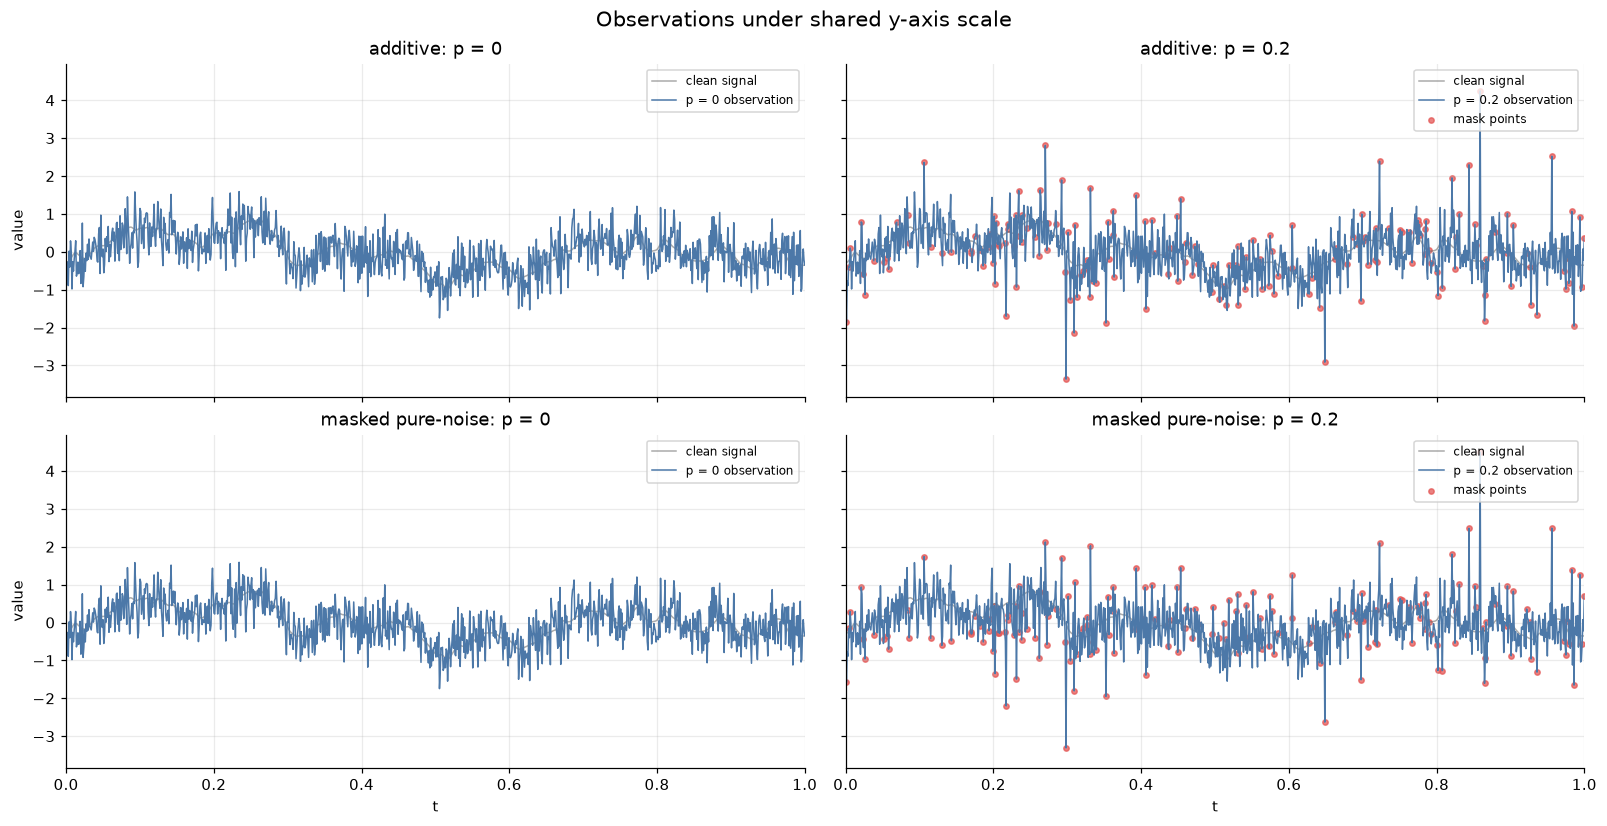

In [4]:
def plot_observations_shared_scale():
    arrays = []
    for ns in single_models.values():
        arrays.extend([ns["x_clean"], ns["y_no_contamination"], ns["y_observed"]])
    y_limits = min_max_limits(*arrays)

    fig, axes = plt.subplots(2, 2, figsize=(14.5, 7.4), sharex=True, sharey=True, constrained_layout=True)
    for row, model in enumerate(["additive", "masked"]):
        ns = single_models[model]
        t = ns["t"]
        axes[row, 0].plot(t, ns["x_clean"], color="#666666", linewidth=1.0, alpha=0.55, label="clean signal")
        axes[row, 0].plot(t, ns["y_no_contamination"], color="#4C78A8", linewidth=1.0, label="p = 0 observation")
        axes[row, 0].set_title(f"{MODEL_SHORT_LABELS[model]}: p = 0")
        axes[row, 0].set_ylabel("value")
        axes[row, 0].set_ylim(*y_limits)

        mask = ns["noise_info"]["contamination_mask"]
        axes[row, 1].plot(t, ns["x_clean"], color="#666666", linewidth=1.0, alpha=0.55, label="clean signal")
        axes[row, 1].plot(t, ns["y_observed"], color="#4C78A8", linewidth=1.0, label="p = 0.2 observation")
        axes[row, 1].scatter(t[mask], ns["y_observed"][mask], color="#E45756", s=12, alpha=0.75, label="mask points")
        axes[row, 1].set_title(f"{MODEL_SHORT_LABELS[model]}: p = 0.2")
        axes[row, 1].set_ylim(*y_limits)

    for ax in axes.ravel():
        ax.margins(x=0.0)
        ax.legend(loc="upper right", fontsize=8)
    for ax in axes[-1, :]:
        ax.set_xlabel("t")
    fig.suptitle("Observations under shared y-axis scale", fontsize=14)
    return fig


fig = plot_observations_shared_scale()
save_figure(fig, "observations_shared_scale.png")
plt.show()

saved figures/gd_imf_observation_model_comparison/robust_imf_grid_top_shared_scale.png


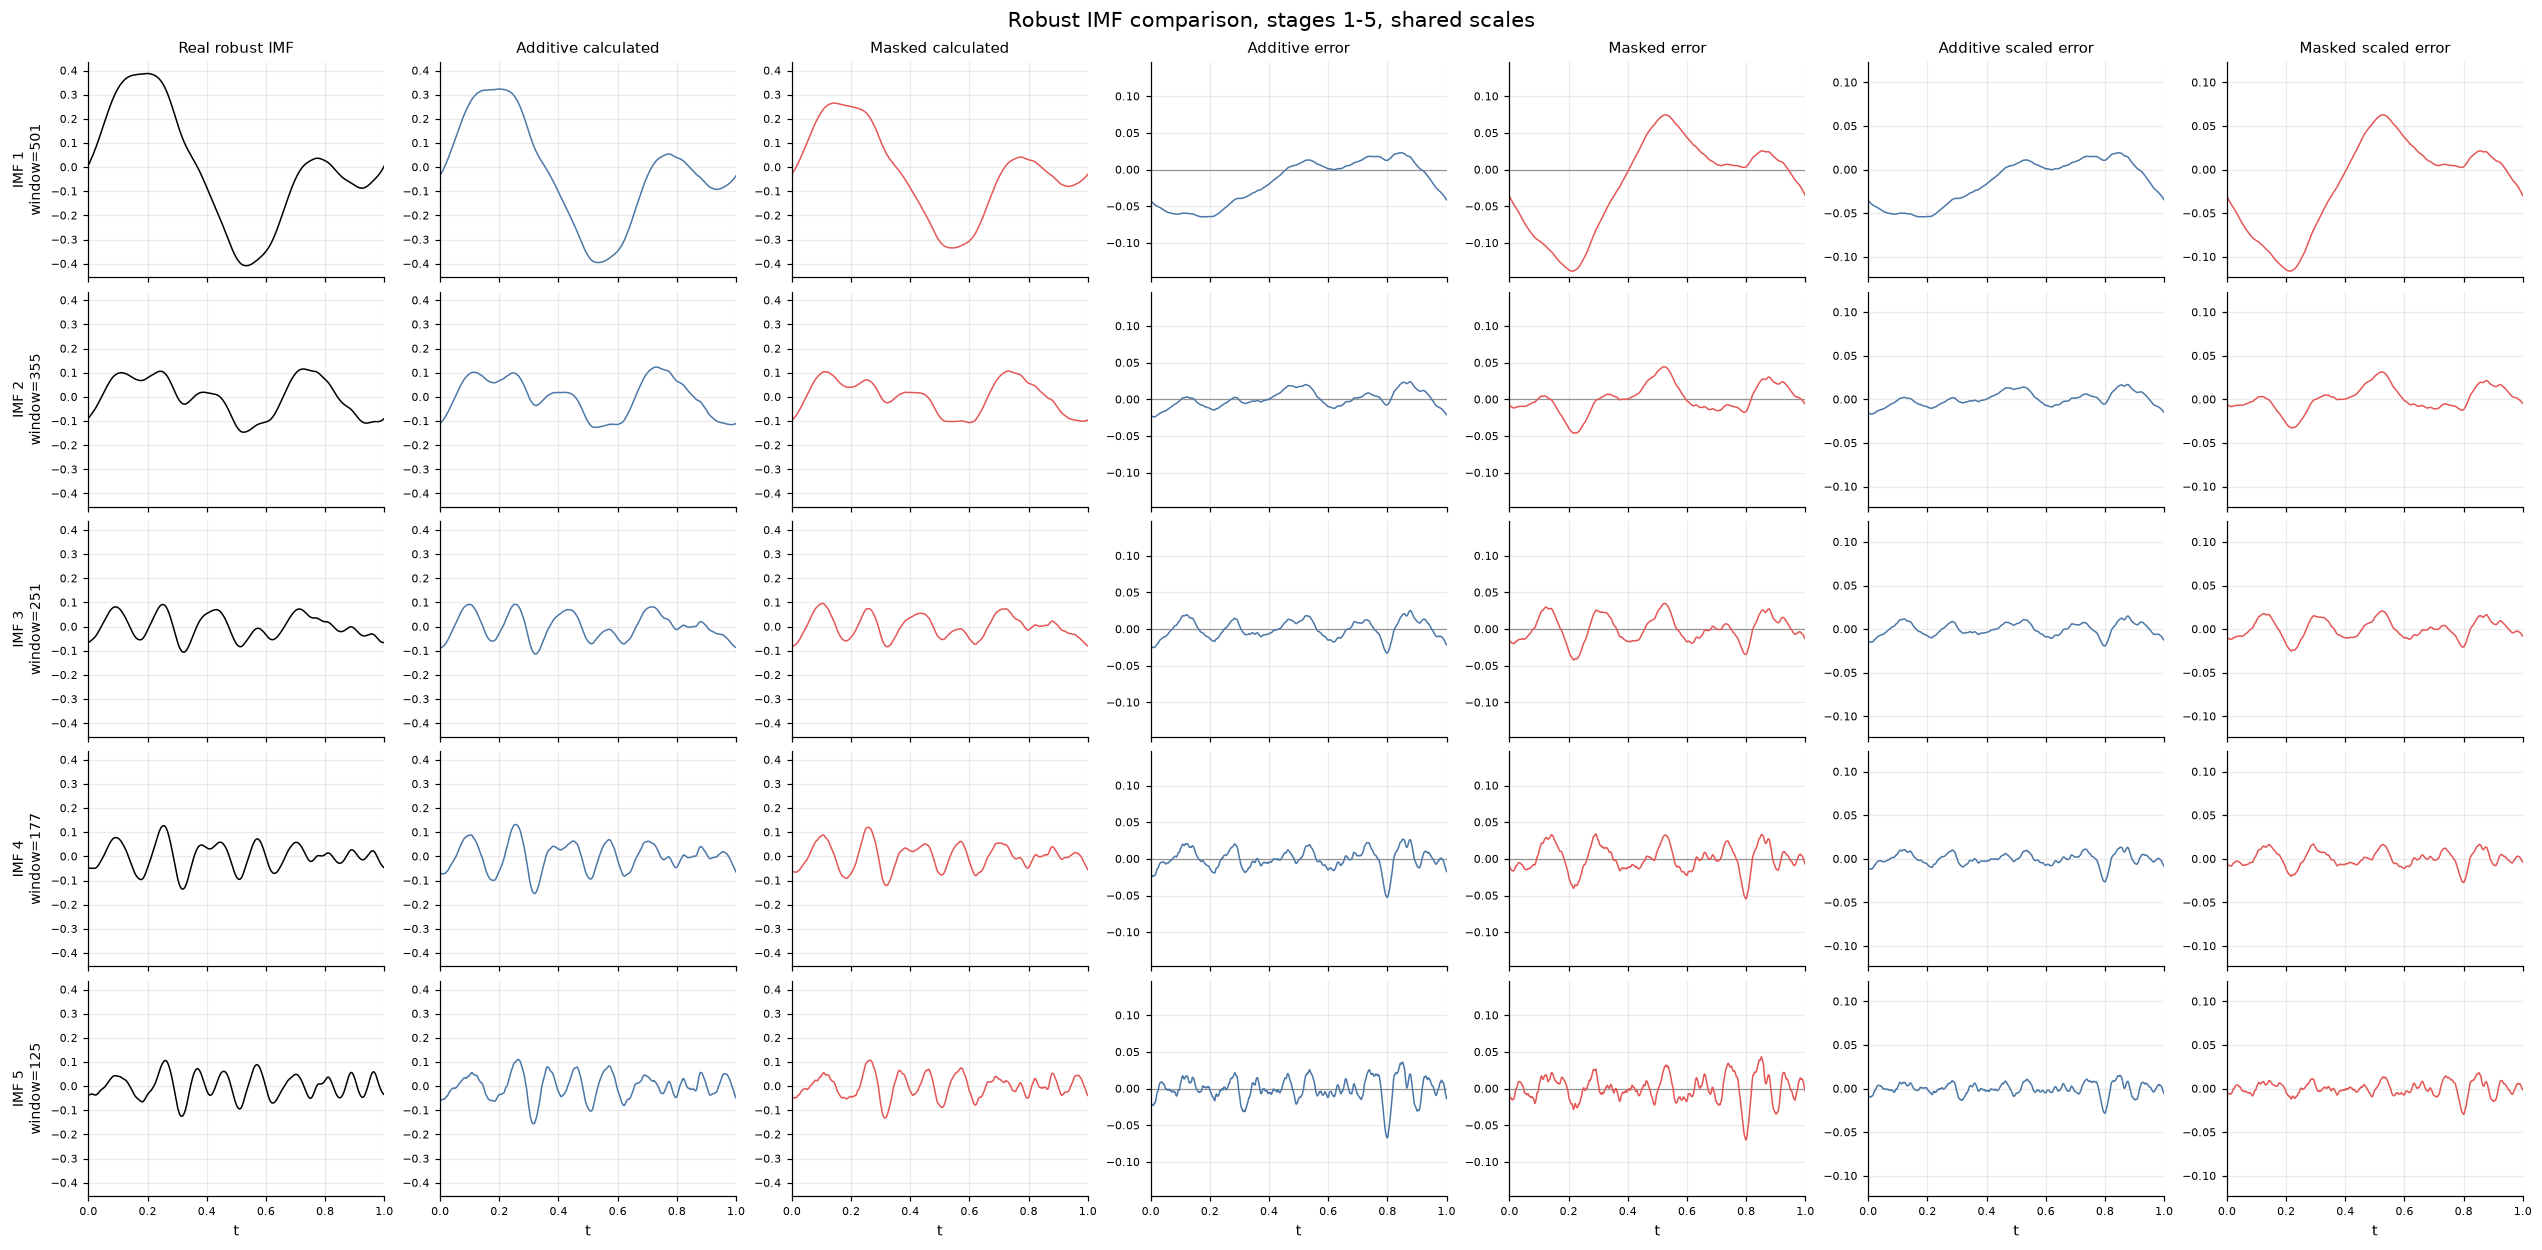

saved figures/gd_imf_observation_model_comparison/robust_imf_grid_bottom_shared_scale.png


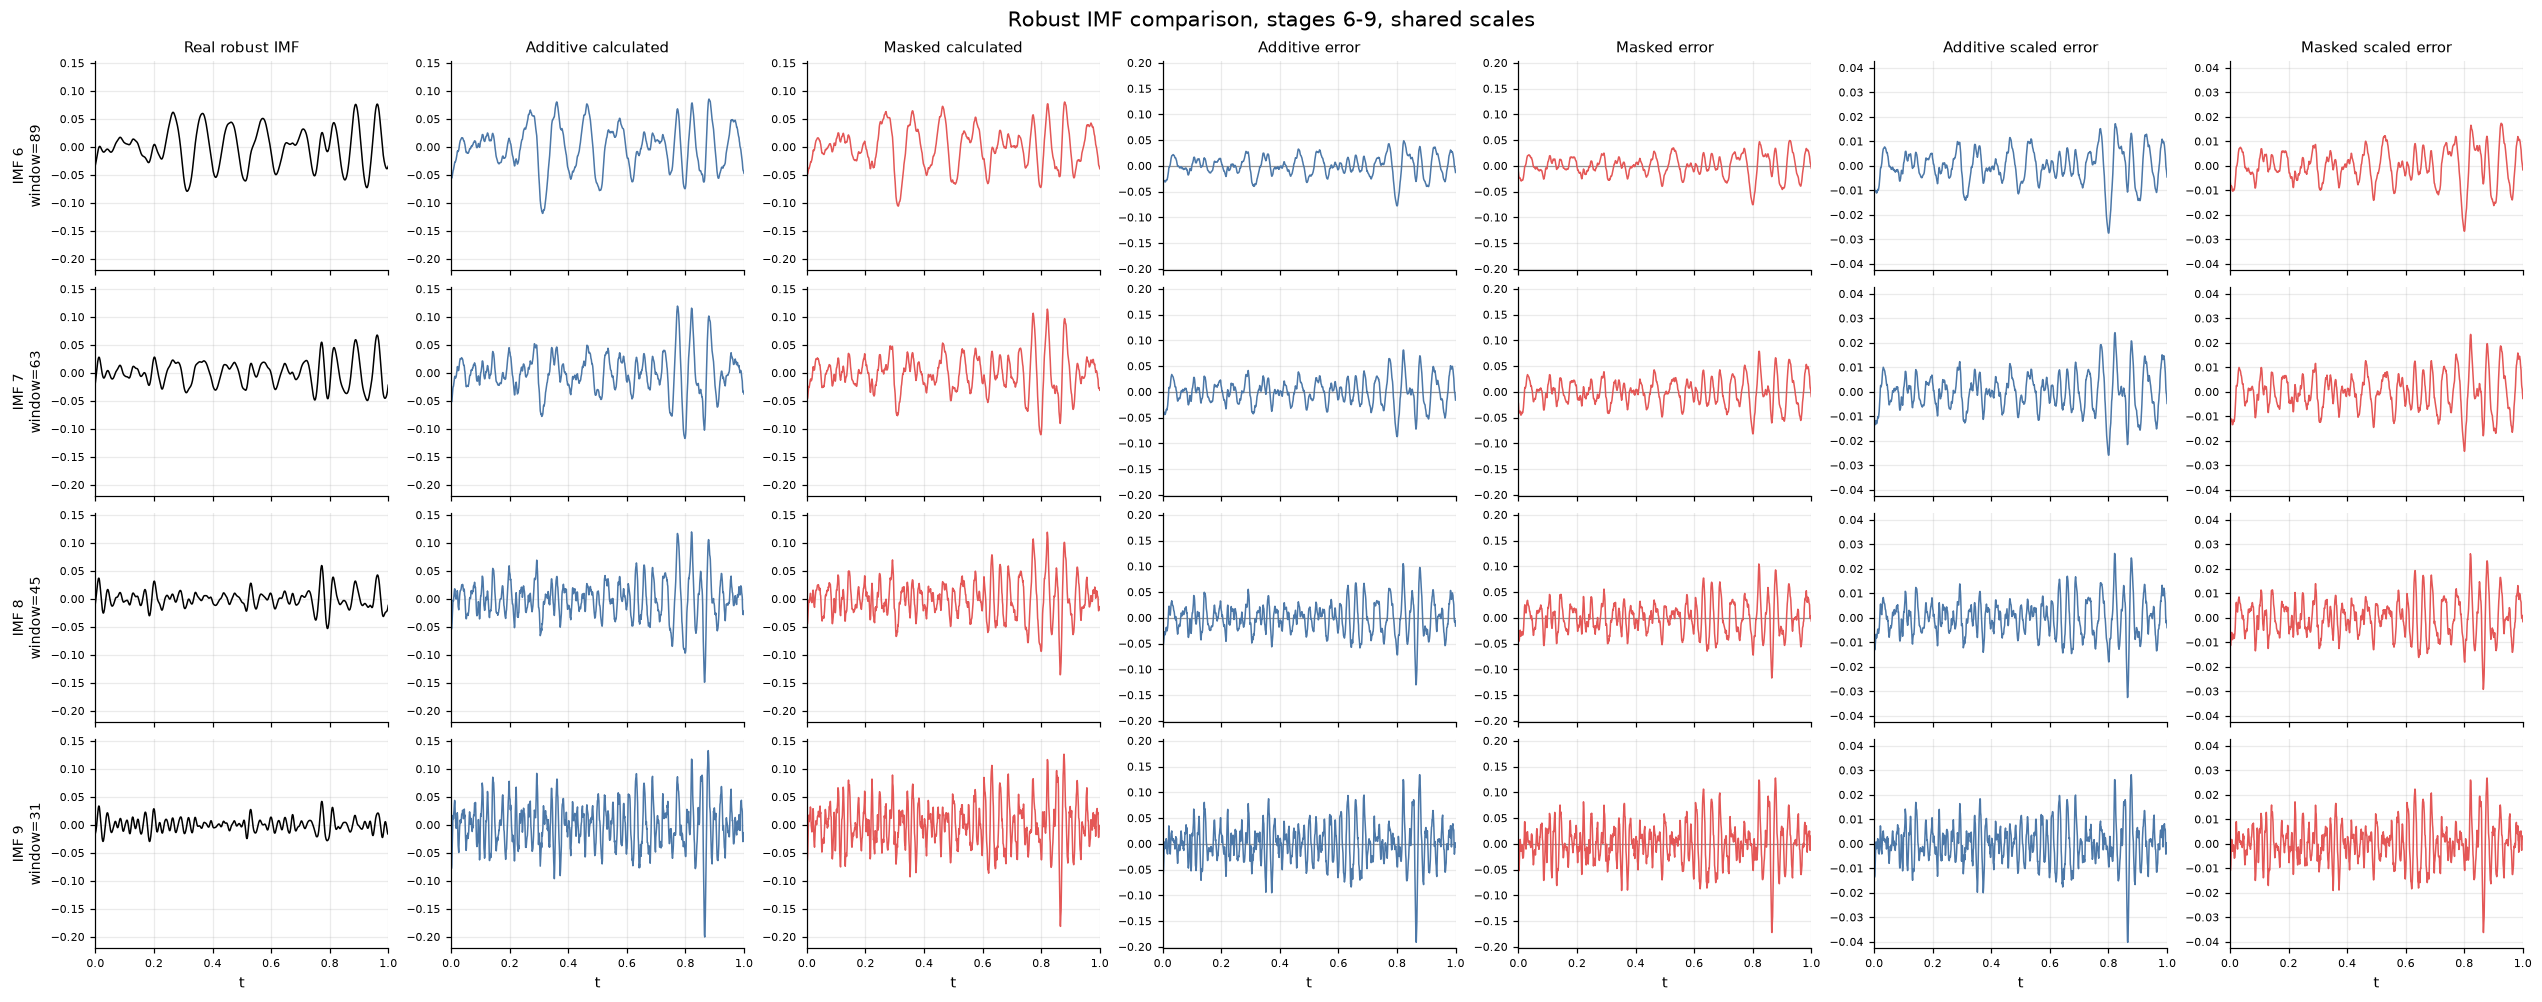

In [5]:
def robust_imf_grid_shared_scale(stages, filename, title):
    add = single_models["additive"]
    masked = single_models["masked"]
    t = add["t"]
    window_sizes = add["window_sizes"]
    scale_error_by_stage = add["scale_error_by_stage"]

    real = np.asarray(add["real_robust"]["imfs"], dtype=float)
    add_calc = np.asarray(add["calculated_robust"]["imfs"], dtype=float)
    masked_calc = np.asarray(masked["calculated_robust"]["imfs"], dtype=float)
    add_err = add_calc - real
    masked_err = masked_calc - real
    stage_indices = np.arange(1, real.shape[0] + 1, dtype=float)[:, None]
    add_scaled = scale_error_by_stage(add_err, stage_indices)
    masked_scaled = scale_error_by_stage(masked_err, stage_indices)

    limits = {
        "imf": min_max_limits(real[stages], add_calc[stages], masked_calc[stages]),
        "error": symmetric_limits(add_err[stages], masked_err[stages]),
        "scaled_error": symmetric_limits(add_scaled[stages], masked_scaled[stages]),
    }

    columns = [
        ("Real robust IMF", "real", "black"),
        ("Additive calculated", "add_calc", "#4C78A8"),
        ("Masked calculated", "masked_calc", "#E45756"),
        ("Additive error", "add_err", "#4C78A8"),
        ("Masked error", "masked_err", "#E45756"),
        ("Additive scaled error", "add_scaled", "#4C78A8"),
        ("Masked scaled error", "masked_scaled", "#E45756"),
    ]
    data = {
        "real": real,
        "add_calc": add_calc,
        "masked_calc": masked_calc,
        "add_err": add_err,
        "masked_err": masked_err,
        "add_scaled": add_scaled,
        "masked_scaled": masked_scaled,
    }

    fig, axes = plt.subplots(len(stages), len(columns), figsize=(23, 2.25 * len(stages)), sharex=True, constrained_layout=True)
    axes = np.atleast_2d(axes)
    for col, (label, _, _) in enumerate(columns):
        axes[0, col].set_title(label, fontsize=10)

    for row, stage_zero in enumerate(stages):
        for col, (_, key, color) in enumerate(columns):
            ax = axes[row, col]
            if "err" in key:
                ax.axhline(0.0, color="#666666", linewidth=0.8, alpha=0.65)
            ax.plot(t, data[key][stage_zero], color=color, linewidth=1.0)
            if key in {"real", "add_calc", "masked_calc"}:
                ax.set_ylim(*limits["imf"])
            elif key in {"add_err", "masked_err"}:
                ax.set_ylim(*limits["error"])
            else:
                ax.set_ylim(*limits["scaled_error"])
            ax.tick_params(axis="both", labelsize=7)
            ax.margins(x=0.0)
        axes[row, 0].set_ylabel(f"IMF {stage_zero + 1}\nwindow={window_sizes[stage_zero]}", fontsize=9)
    for ax in axes[-1, :]:
        ax.set_xlabel("t")
    fig.suptitle(title, fontsize=14)
    save_figure(fig, filename)
    return fig


fig = robust_imf_grid_shared_scale(
    stages=np.arange(0, 5),
    filename="robust_imf_grid_top_shared_scale.png",
    title="Robust IMF comparison, stages 1-5, shared scales",
)
plt.show()

fig = robust_imf_grid_shared_scale(
    stages=np.arange(5, 9),
    filename="robust_imf_grid_bottom_shared_scale.png",
    title="Robust IMF comparison, stages 6-9, shared scales",
)
plt.show()

saved figures/gd_imf_observation_model_comparison/robust_rmse_trends_shared_scale.png


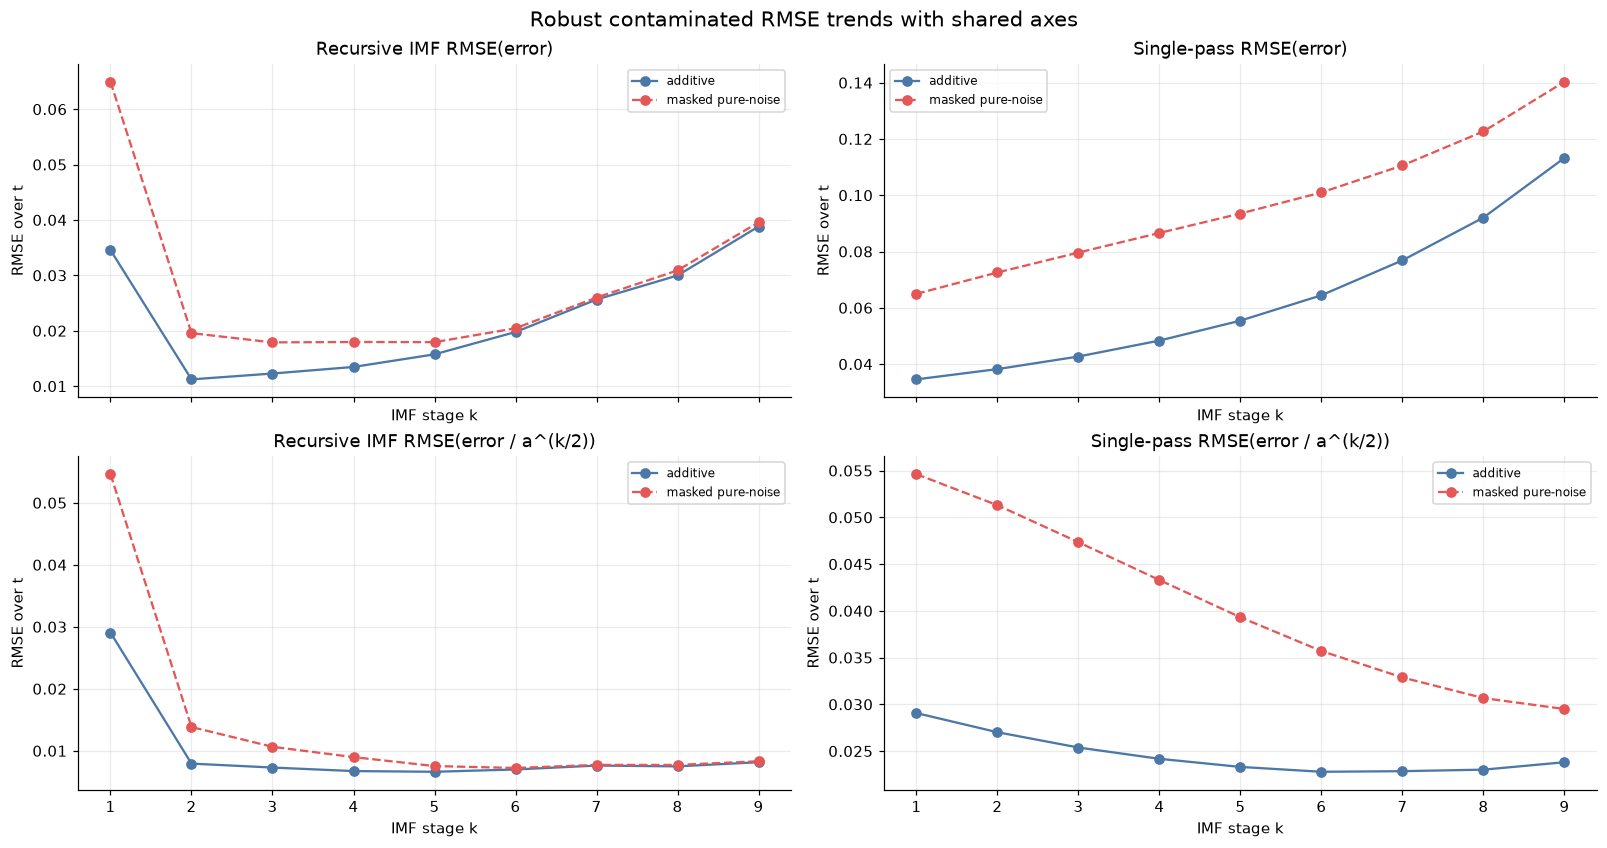

,observation_model,metric,slope,intercept
0,additive,Recursive IMF RMSE(error),0.001771,0.013530
1,masked,Recursive IMF RMSE(error),-0.000815,0.032436
2,additive,Single-pass RMSE(error),0.009346,0.016147
3,masked,Single-pass RMSE(error),0.008803,0.052848
4,additive,Recursive IMF RMSE(error / a^(k/2)),-0.001401,0.016774
5,masked,Recursive IMF RMSE(error / a^(k/2)),-0.003519,0.031665
6,additive,Single-pass RMSE(error / a^(k/2)),-0.000658,0.027893
7,masked,Single-pass RMSE(error / a^(k/2)),-0.003315,0.057087


saved figures/gd_imf_observation_model_comparison/robust_sup_error_trends_shared_scale.png


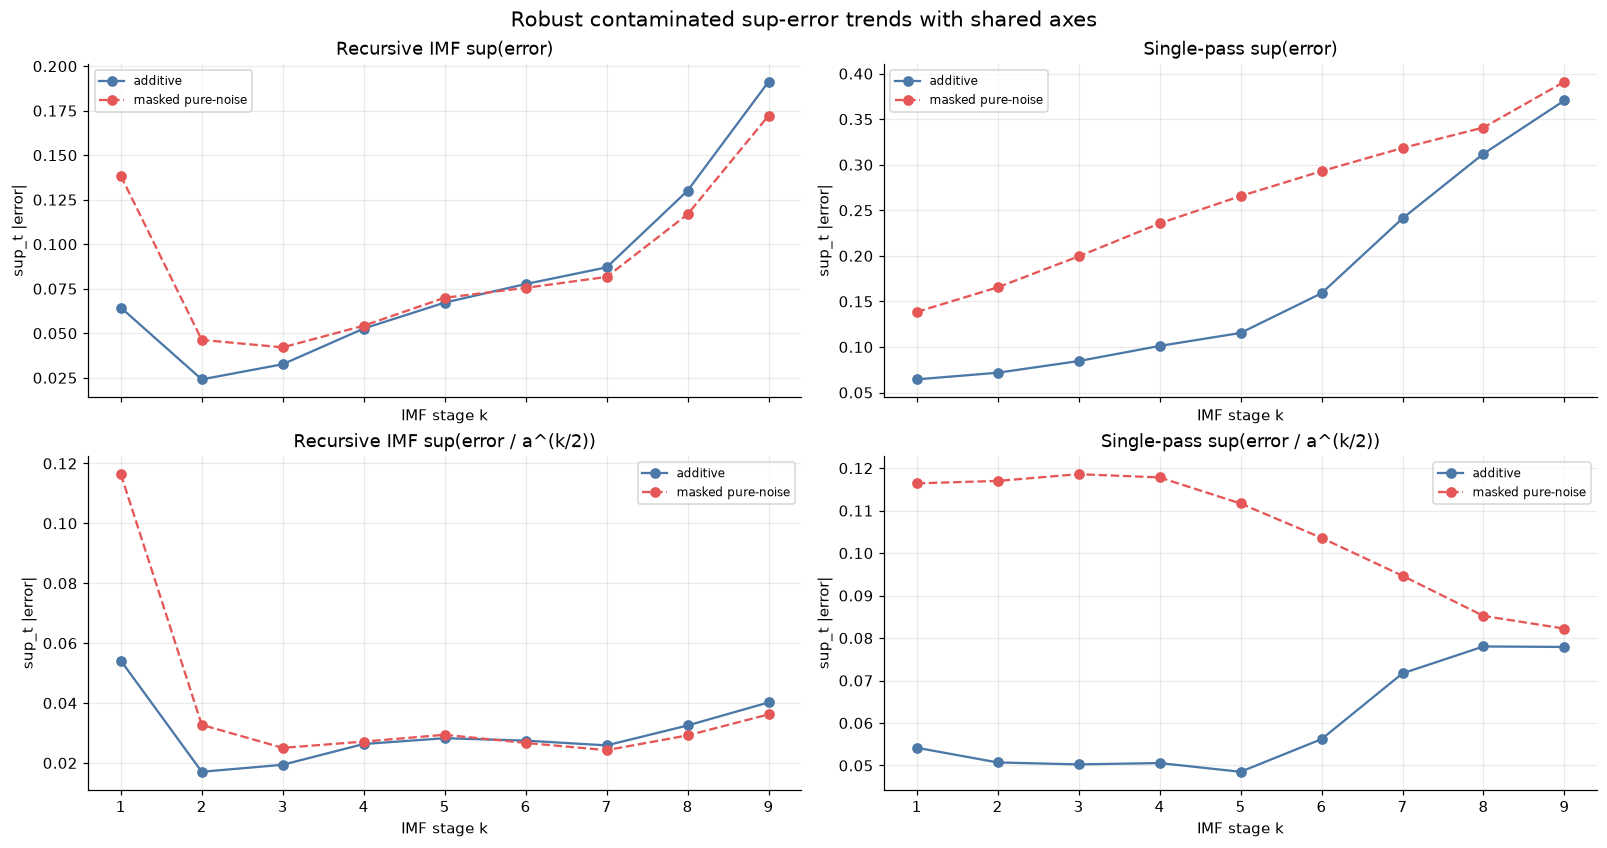

,observation_model,metric,slope,intercept
0,additive,Recursive IMF sup(error),0.015981,0.000872
1,masked,Recursive IMF sup(error),0.007450,0.051328
2,additive,Single-pass sup(error),0.038613,-0.024180
3,masked,Single-pass sup(error),0.030536,0.108203
4,additive,Recursive IMF sup(error / a^(k/2)),0.000076,0.029760
5,masked,Recursive IMF sup(error / a^(k/2)),-0.005556,0.066346
6,additive,Single-pass sup(error / a^(k/2)),0.003755,0.041007
7,masked,Single-pass sup(error / a^(k/2)),-0.004903,0.129759


In [6]:
def plot_metric_trends_shared(case_name, metrics, title, ylabel, filename):
    fig, axes = plt.subplots(2, 2, figsize=(14.5, 7.6), sharex=True, constrained_layout=True)
    axes = np.ravel(axes)
    coefficient_rows = []

    for ax, (column, label) in zip(axes, metrics):
        y_values = []
        x_values = []
        for model, ns in single_models.items():
            frame = ns["error_summary"].loc[ns["error_summary"]["case"] == case_name].copy()
            x = frame["stage"].to_numpy(dtype=float)
            y = frame[column].to_numpy(dtype=float)
            y_values.append(y)
            x_values.append(x)
            slope, intercept = ns["fit_line"](x, y)
            coefficient_rows.append({
                "observation_model": model,
                "metric": label,
                "slope": slope,
                "intercept": intercept,
            })
        y_limits = min_max_limits(*y_values)
        for model, ns in single_models.items():
            frame = ns["error_summary"].loc[ns["error_summary"]["case"] == case_name].copy()
            ax.plot(
                frame["stage"],
                frame[column],
                marker="o",
                color=MODEL_COLORS[model],
                linestyle=MODEL_LINESTYLES[model],
                linewidth=1.5,
                label=MODEL_SHORT_LABELS[model],
            )
        ax.set_title(label)
        ax.set_xlabel("IMF stage k")
        ax.set_ylabel(ylabel)
        ax.set_xticks(single_models["additive"]["window_schedule_df"]["stage"])
        ax.set_ylim(*y_limits)
        ax.legend(loc="best", fontsize=8)
    fig.suptitle(title, fontsize=14)
    save_figure(fig, filename)
    coefficients = pd.DataFrame(coefficient_rows)
    return fig, coefficients


rmse_metrics = [
    ("recursive_error_rmse", "Recursive IMF RMSE(error)"),
    ("single_pass_error_rmse", "Single-pass RMSE(error)"),
    ("recursive_scaled_error_rmse", "Recursive IMF RMSE(error / a^(k/2))"),
    ("single_pass_scaled_error_rmse", "Single-pass RMSE(error / a^(k/2))"),
]
sup_metrics = [
    ("recursive_sup_error", "Recursive IMF sup(error)"),
    ("single_pass_sup_error", "Single-pass sup(error)"),
    ("recursive_scaled_sup_error", "Recursive IMF sup(error / a^(k/2))"),
    ("single_pass_scaled_sup_error", "Single-pass sup(error / a^(k/2))"),
]

fig, robust_rmse_coefficients = plot_metric_trends_shared(
    "p = 0.2 / robust",
    rmse_metrics,
    "Robust contaminated RMSE trends with shared axes",
    "RMSE over t",
    "robust_rmse_trends_shared_scale.png",
)
plt.show()
display(robust_rmse_coefficients)

fig, robust_sup_coefficients = plot_metric_trends_shared(
    "p = 0.2 / robust",
    sup_metrics,
    "Robust contaminated sup-error trends with shared axes",
    "sup_t |error|",
    "robust_sup_error_trends_shared_scale.png",
)
plt.show()
display(robust_sup_coefficients)

saved figures/gd_imf_observation_model_comparison/robust_error_boxplots_shared_scale.png


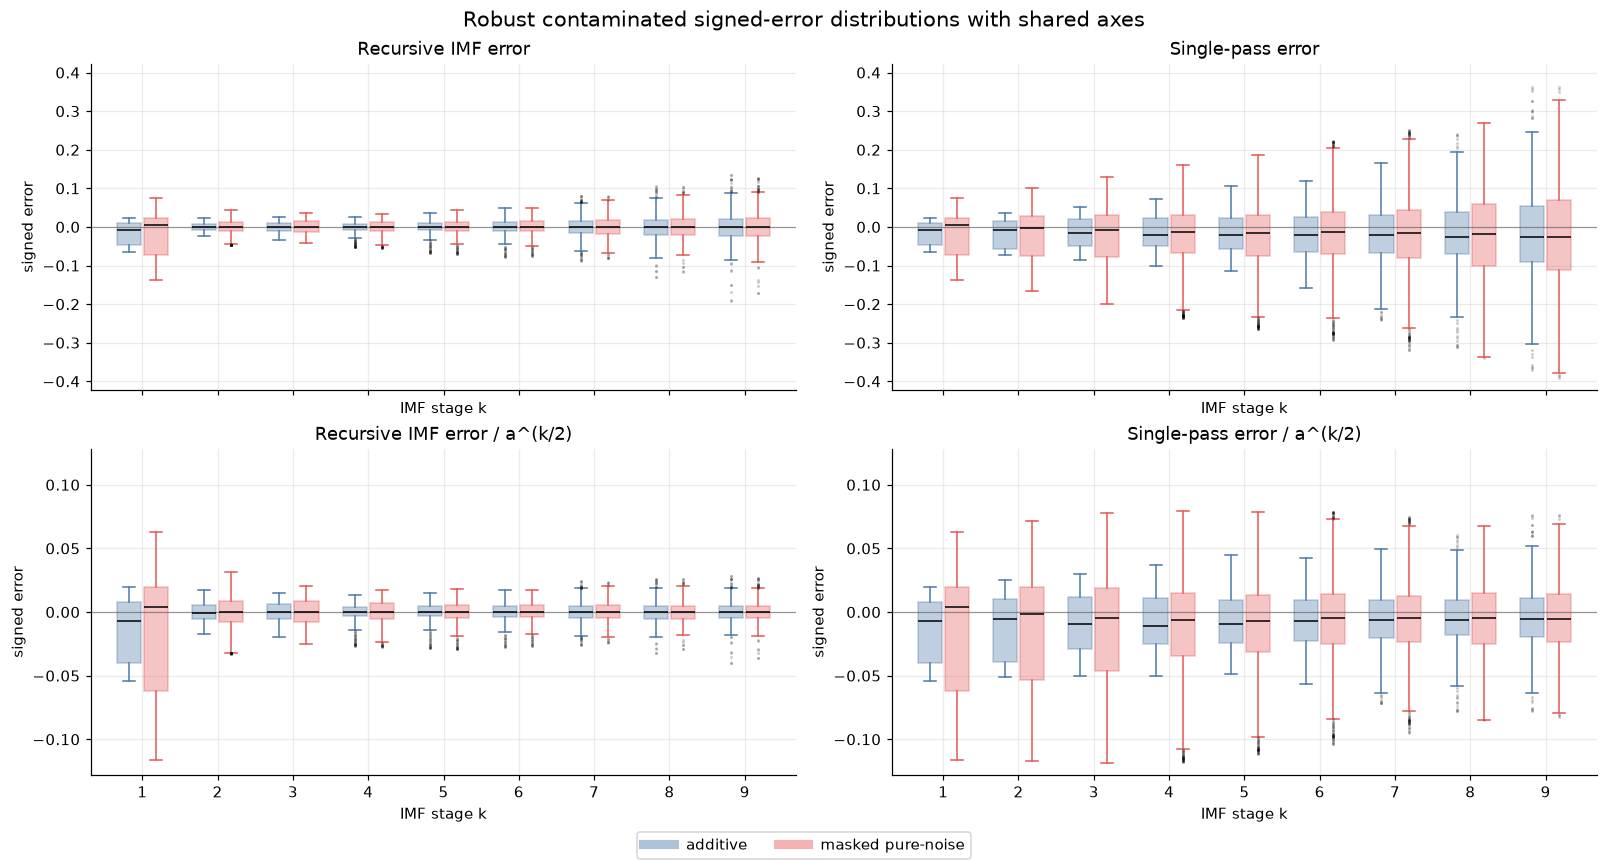

In [7]:
def plot_error_boxplots_shared(case_name, filename):
    panels = [
        ("recursive", "raw", "Recursive IMF error"),
        ("single_pass", "raw", "Single-pass error"),
        ("recursive", "a^(k/2)", "Recursive IMF error / a^(k/2)"),
        ("single_pass", "a^(k/2)", "Single-pass error / a^(k/2)"),
    ]
    stages = np.asarray(sorted(single_models["additive"]["error_values"].loc[
        single_models["additive"]["error_values"]["case"] == case_name,
        "stage",
    ].unique()), dtype=int)
    y_limits = {}
    for scale in ["raw", "a^(k/2)"]:
        values = []
        for ns in single_models.values():
            frame = ns["error_values"]
            values.append(frame.loc[(frame["case"] == case_name) & (frame["scale"] == scale), "error_value"])
        y_limits[scale] = symmetric_limits(*values, pad_fraction=0.08)

    fig, axes = plt.subplots(2, 2, figsize=(14.5, 7.8), sharex=True, constrained_layout=True)
    axes = np.ravel(axes)
    offsets = {"additive": -0.18, "masked": 0.18}

    for ax, (family, scale, title) in zip(axes, panels):
        for model, ns in single_models.items():
            frame = ns["error_values"].loc[
                (ns["error_values"]["case"] == case_name)
                & (ns["error_values"]["error_family"] == family)
                & (ns["error_values"]["scale"] == scale)
            ]
            data = [frame.loc[frame["stage"] == stage, "error_value"].to_numpy(dtype=float) for stage in stages]
            positions = stages + offsets[model]
            boxplot = ax.boxplot(
                data,
                positions=positions,
                widths=0.32,
                patch_artist=True,
                tick_labels=[str(stage) for stage in stages] if model == "additive" else None,
                flierprops={"marker": ".", "markersize": 1.8, "alpha": 0.20},
                medianprops={"color": "black", "linewidth": 1.0},
            )
            for patch in boxplot["boxes"]:
                patch.set_facecolor(MODEL_COLORS[model])
                patch.set_alpha(0.35)
                patch.set_edgecolor(MODEL_COLORS[model])
            for whisker in boxplot["whiskers"]:
                whisker.set_color(MODEL_COLORS[model])
            for cap in boxplot["caps"]:
                cap.set_color(MODEL_COLORS[model])
        ax.axhline(0.0, color="#666666", linewidth=0.8, alpha=0.65)
        ax.set_title(title)
        ax.set_xlabel("IMF stage k")
        ax.set_ylabel("signed error")
        ax.set_ylim(*y_limits[scale])
        ax.set_xticks(stages)
        ax.set_xticklabels([str(stage) for stage in stages])

    handles = [
        plt.Line2D([0], [0], color=MODEL_COLORS[model], lw=6, alpha=0.45, label=MODEL_SHORT_LABELS[model])
        for model in ["additive", "masked"]
    ]
    fig.legend(handles=handles, loc="outside lower center", ncol=2)
    fig.suptitle("Robust contaminated signed-error distributions with shared axes", fontsize=14)
    save_figure(fig, filename)
    return fig


fig = plot_error_boxplots_shared("p = 0.2 / robust", "robust_error_boxplots_shared_scale.png")
plt.show()

## Limit-sweep model data

This recomputes both limit sweeps in isolated namespaces. The runtime is dominated by the two 960-trial coarse sweeps.

In [8]:
LIMIT_SELECTED_CELLS = [3, 5, 7, 9, 10, 12, 14, 16, 18, 20, 22]

limit_models = {
    model: execute_source_cells(path, LIMIT_SELECTED_CELLS, label=f"limit-sweep {model}")
    for model, path in LIMIT_MODEL_SOURCES.items()
}

for model, ns in limit_models.items():
    assert len(ns["coarse_parameter_grid"]) == 320
    assert len(ns["coarse_trials"]) == 960
    assert len(ns["aggregate_metrics"]) == 1920
    assert len(ns["surface_summary"]) == 640
    assert set(ns["aggregate_metrics"]["method"].unique()) == {"linear", "robust"}

limit_validation = pd.DataFrame([
    {"observation_model": model, "coarse parameter points": len(ns["coarse_parameter_grid"]), "trials": len(ns["coarse_trials"]), "aggregate rows": len(ns["aggregate_metrics"]), "surface rows": len(ns["surface_summary"])}
    for model, ns in limit_models.items()
])
limit_validation

loading limit-sweep additive: gd_imf_real_vs_calculated_limits.ipynb


precomputed clean references for 5 sigma values in 0.27 seconds
coarse sweep: trial 1 / 960


coarse sweep: trial 100 / 960


coarse sweep: trial 200 / 960


coarse sweep: trial 300 / 960


...

coarse sweep: trial 800 / 960


coarse sweep: trial 900 / 960


coarse sweep: trial 960 / 960
coarse sweep: completed 960 trials in 116.17 seconds


loaded limit-sweep masked in 116.60 seconds


,observation_model,coarse parameter points,trials,aggregate rows,surface rows
0,additive,320,960,1920,640
1,masked,320,960,1920,640


## Limit-sweep shared-scale figures

These plots use color normalizations and y-axis limits computed across both observation models.

saved figures/gd_imf_observation_model_comparison/error_surfaces_mean_scaled_rmse_shared_scale.png


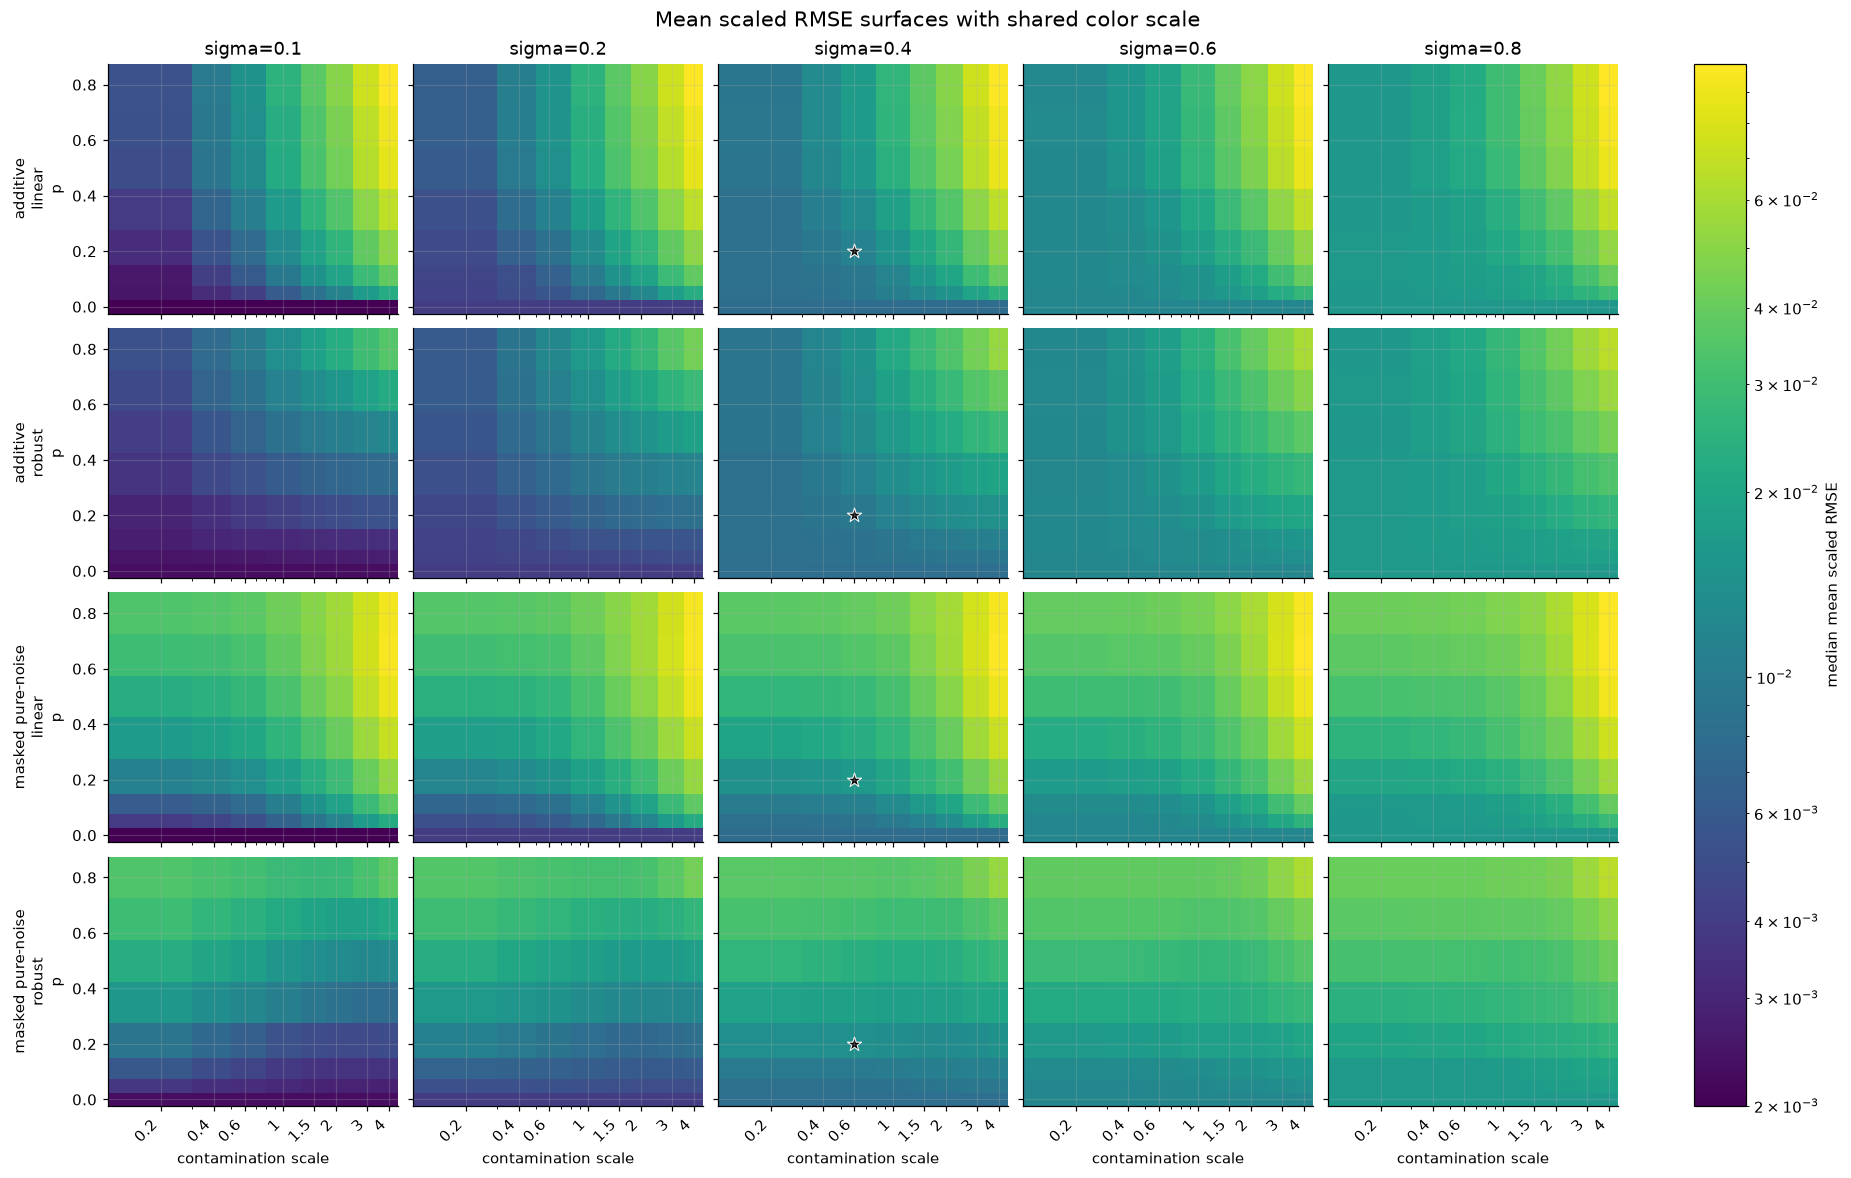

saved figures/gd_imf_observation_model_comparison/error_surfaces_max_scaled_sup_error_shared_scale.png


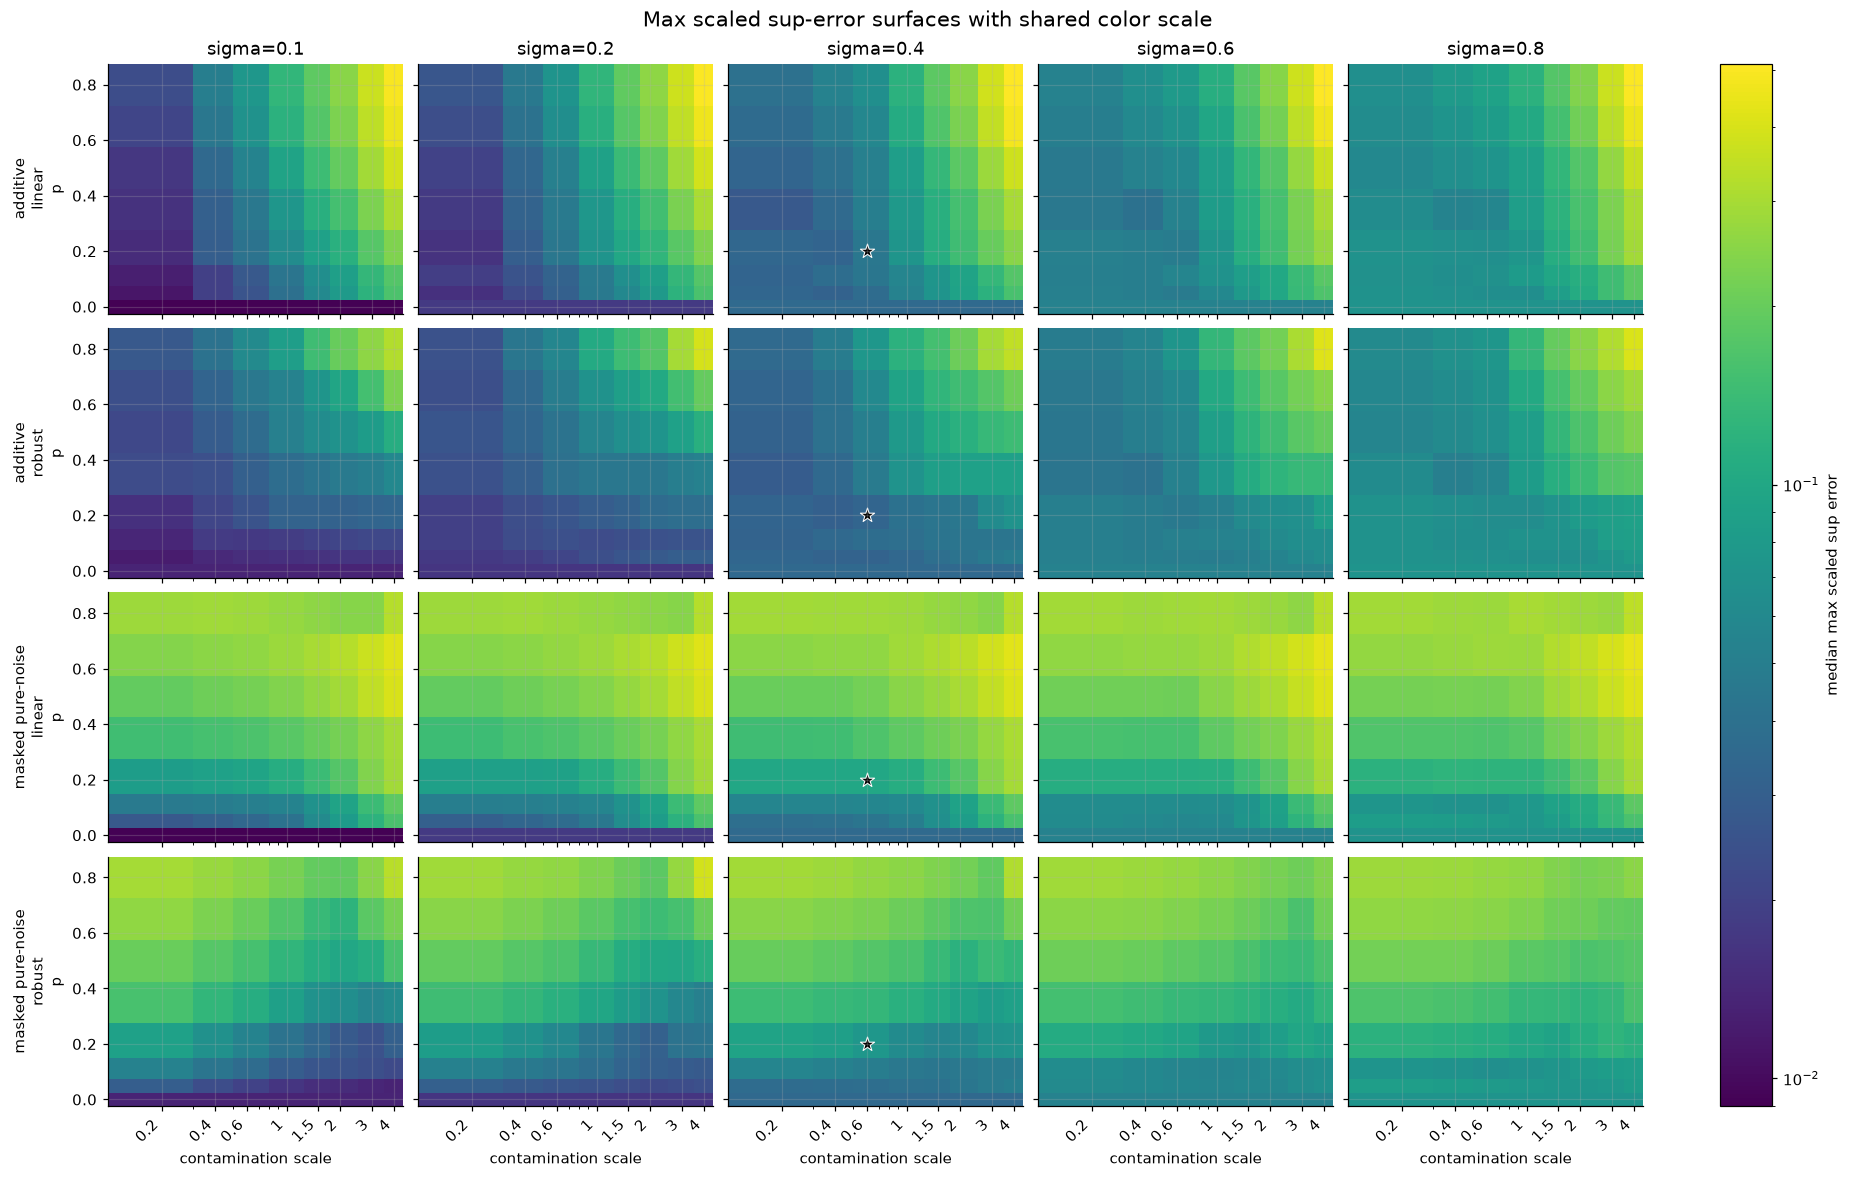

In [9]:
def surface_frame_with_model():
    return pd.concat(
        [ns["surface_summary"].assign(observation_model=model) for model, ns in limit_models.items()],
        ignore_index=True,
    )


def aggregate_frame_with_model():
    return pd.concat(
        [ns["aggregate_metrics"].assign(observation_model=model) for model, ns in limit_models.items()],
        ignore_index=True,
    )


surface_by_model = surface_frame_with_model()
aggregate_by_model = aggregate_frame_with_model()


def pivot_metric(panel, metric_column):
    table = panel.pivot_table(
        index="contamination_probability",
        columns="contamination_scale",
        values=metric_column,
        aggfunc="first",
    )
    return table.sort_index().sort_index(axis=1)


def plot_surface_heatmaps_shared(metric, filename, title, colorbar_label=None):
    metric_column = f"{metric}_median"
    frame = surface_by_model.loc[surface_by_model["grid_level"] == "coarse"].copy()
    values = frame[metric_column].to_numpy(dtype=float)
    positive = values[np.isfinite(values) & (values > 0)]
    norm = LogNorm(vmin=float(np.min(positive)), vmax=float(np.max(positive)))
    models = ["additive", "masked"]
    methods = ["linear", "robust"]
    sigmas = np.asarray(sorted(frame["sigma"].unique()), dtype=float)

    fig, axes = plt.subplots(len(models) * len(methods), len(sigmas), figsize=(3.35 * len(sigmas), 10.6), sharex=True, sharey=True, constrained_layout=True)
    last_mesh = None
    for row_model, model in enumerate(models):
        for row_method, method in enumerate(methods):
            row = row_model * len(methods) + row_method
            for col, sigma_value in enumerate(sigmas):
                ax = axes[row, col]
                panel = frame.loc[
                    (frame["observation_model"] == model)
                    & (frame["method"] == method)
                    & np.isclose(frame["sigma"], sigma_value)
                ]
                table = pivot_metric(panel, metric_column)
                x_centers = table.columns.to_numpy(dtype=float)
                y_centers = table.index.to_numpy(dtype=float)
                last_mesh = ax.pcolormesh(
                    centers_to_edges(x_centers),
                    centers_to_edges(y_centers),
                    table.to_numpy(dtype=float),
                    cmap="viridis",
                    norm=norm,
                    shading="auto",
                )
                current = limit_models["additive"]
                if np.isclose(sigma_value, current["CURRENT_SIGMA"]):
                    ax.scatter(
                        [current["CURRENT_CONTAMINATION_SCALE"]],
                        [current["CURRENT_CONTAMINATION_PROB"]],
                        marker="*",
                        s=95,
                        color="black",
                        edgecolor="white",
                        linewidth=0.7,
                    )
                if row == 0:
                    ax.set_title(f"sigma={sigma_value:g}")
                if col == 0:
                    ax.set_ylabel(f"{MODEL_SHORT_LABELS[model]}\n{method}\np")
                if row == len(models) * len(methods) - 1:
                    ax.set_xlabel("contamination scale")
                ax.set_xscale("log")
                ax.set_xticks(limit_models["additive"]["contamination_scale_grid"])
                ax.set_xticklabels([f"{value:g}" for value in limit_models["additive"]["contamination_scale_grid"]], rotation=45, ha="right")
    fig.colorbar(last_mesh, ax=axes.ravel().tolist(), label=colorbar_label or metric_column)
    fig.suptitle(title, fontsize=14)
    save_figure(fig, filename)
    return fig


fig = plot_surface_heatmaps_shared(
    "mean_scaled_rmse",
    "error_surfaces_mean_scaled_rmse_shared_scale.png",
    "Mean scaled RMSE surfaces with shared color scale",
    "median mean scaled RMSE",
)
plt.show()

fig = plot_surface_heatmaps_shared(
    "max_scaled_sup_error",
    "error_surfaces_max_scaled_sup_error_shared_scale.png",
    "Max scaled sup-error surfaces with shared color scale",
    "median max scaled sup error",
)
plt.show()

saved figures/gd_imf_observation_model_comparison/baseline_degradation_mean_scaled_rmse_shared_scale.png


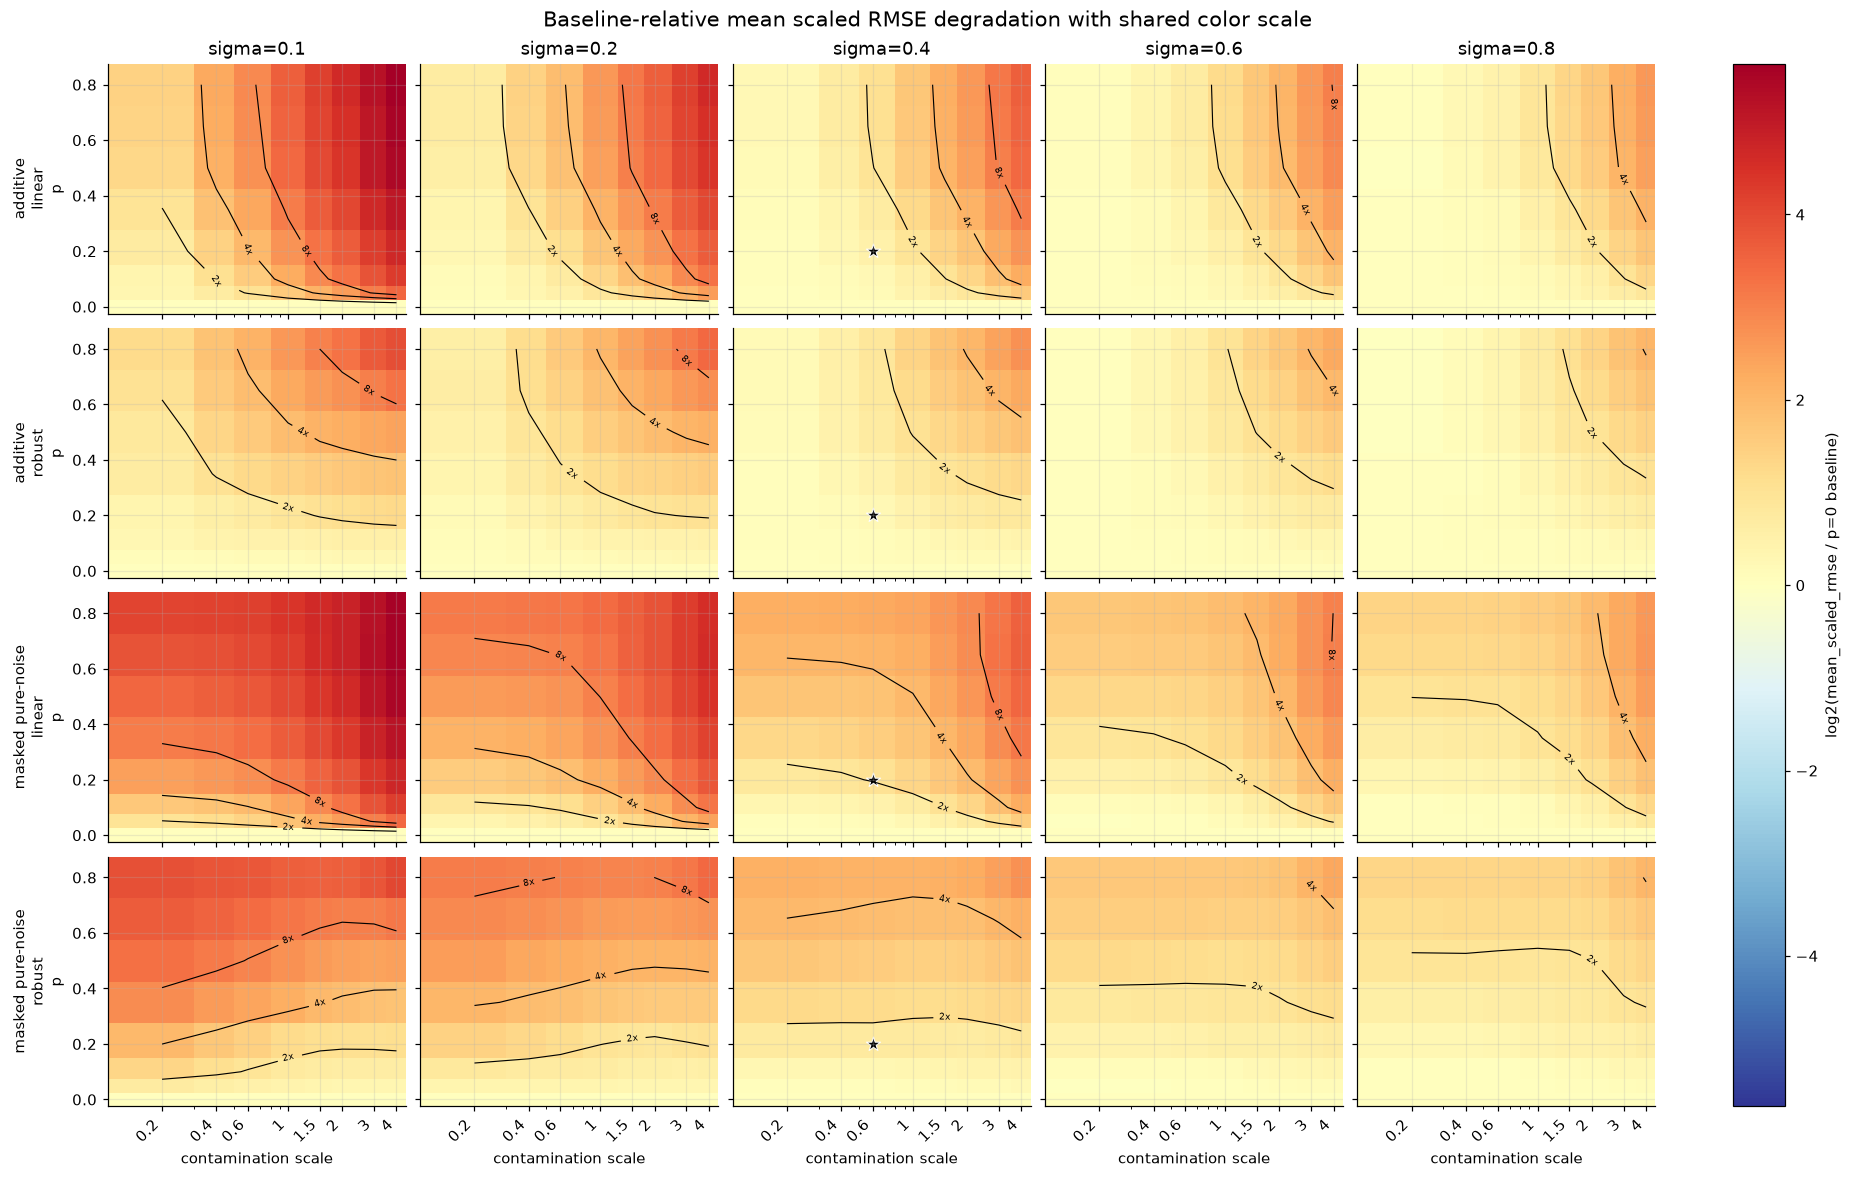

saved figures/gd_imf_observation_model_comparison/baseline_degradation_max_scaled_sup_error_shared_scale.png


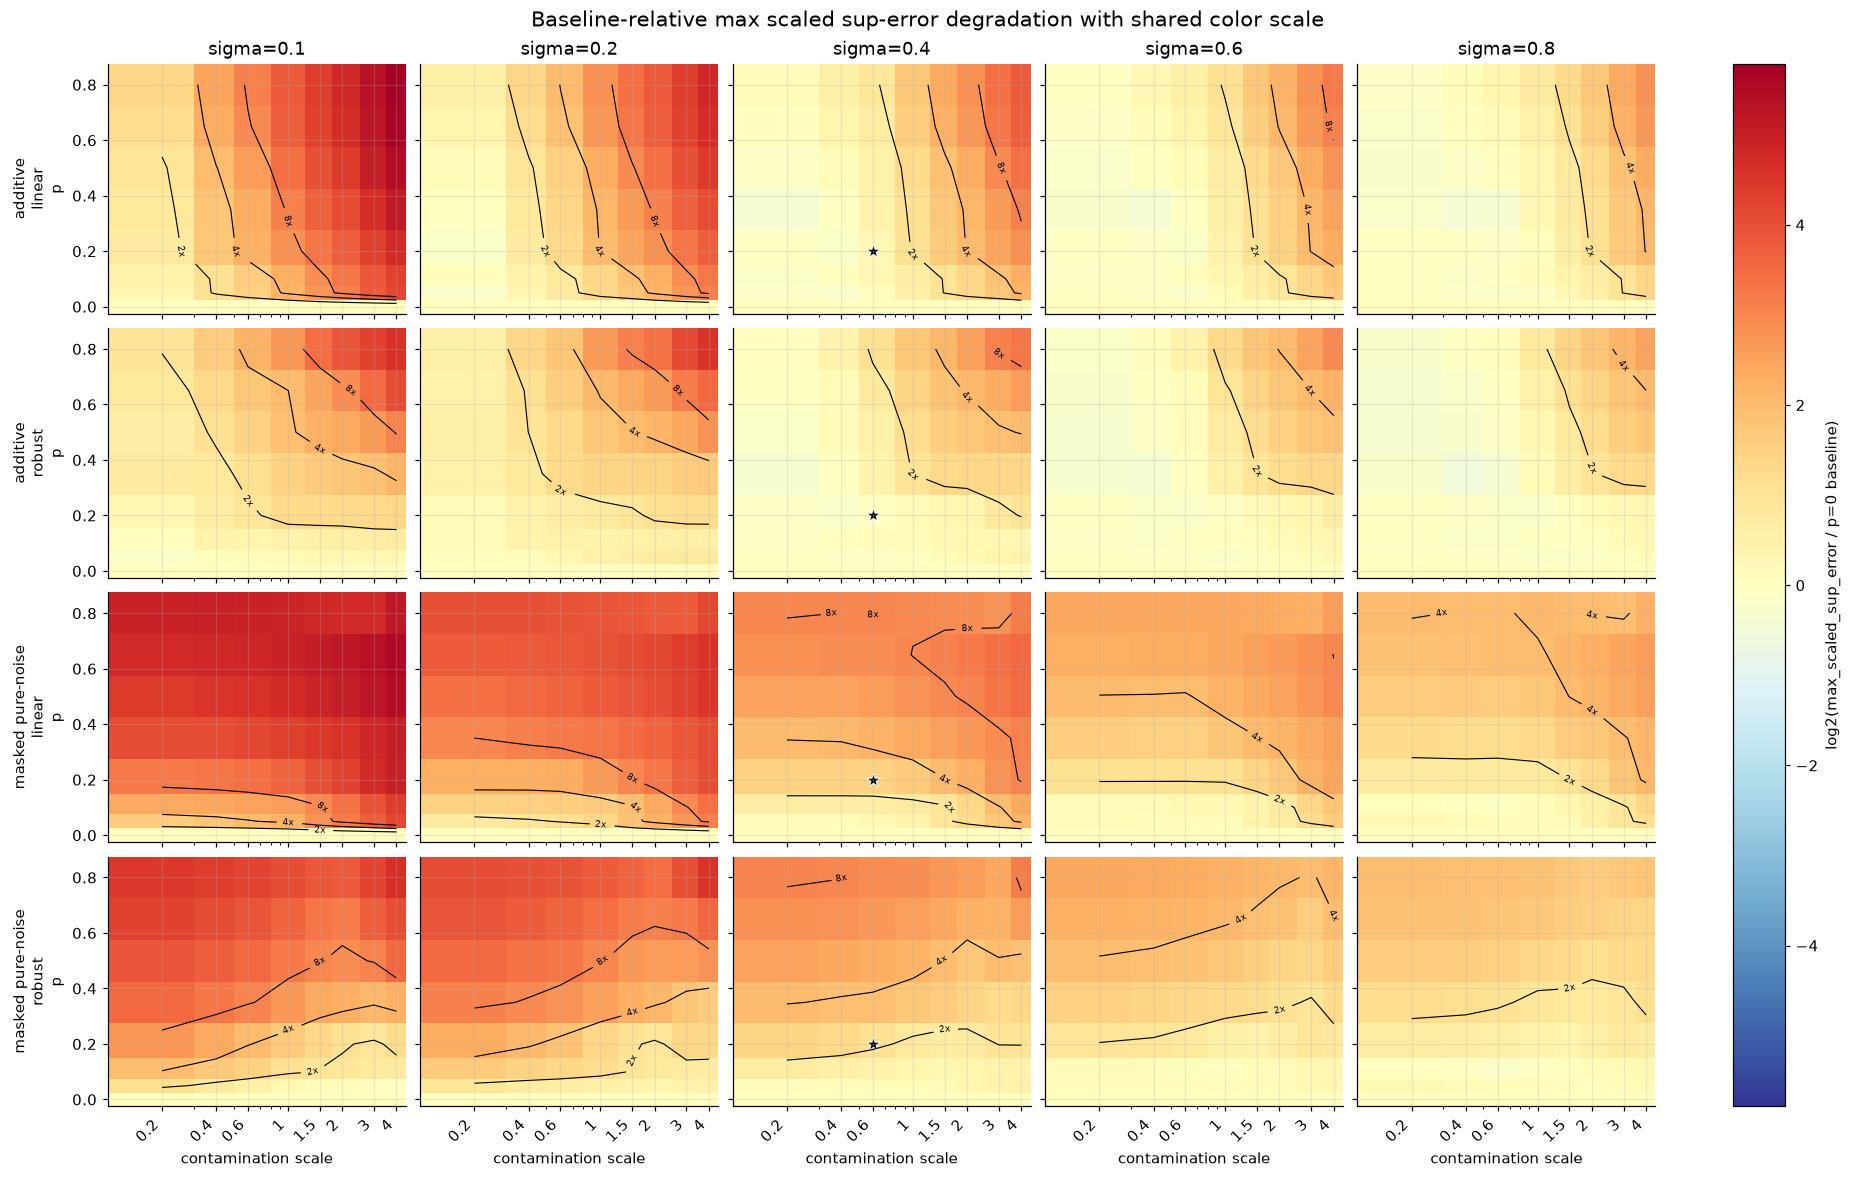

In [10]:
def baseline_degradation_frame_for_model(model, metric):
    metric_column = f"{metric}_median"
    coarse = limit_models[model]["surface_summary"].loc[
        limit_models[model]["surface_summary"]["grid_level"] == "coarse"
    ].copy()
    baseline = coarse.loc[np.isclose(coarse["contamination_probability"], 0.0), [
        "method",
        "sigma",
        "contamination_scale",
        metric_column,
    ]].rename(columns={metric_column: "baseline_value"})
    merged = coarse.merge(
        baseline,
        on=["method", "sigma", "contamination_scale"],
        how="left",
        validate="many_to_one",
    )
    merged["degradation_ratio"] = merged[metric_column] / merged["baseline_value"]
    merged["log2_degradation_ratio"] = np.log2(np.maximum(merged["degradation_ratio"], 1e-12))
    merged["observation_model"] = model
    return merged


def degradation_frame_with_model(metric):
    return pd.concat(
        [baseline_degradation_frame_for_model(model, metric) for model in ["additive", "masked"]],
        ignore_index=True,
    )


def plot_baseline_degradation_shared(metric, filename, title):
    frame = degradation_frame_with_model(metric)
    values = frame["log2_degradation_ratio"].to_numpy(dtype=float)
    limit = max(1.0, float(np.nanmax(np.abs(values))))
    norm = TwoSlopeNorm(vmin=-limit, vcenter=0.0, vmax=limit)
    models = ["additive", "masked"]
    methods = ["linear", "robust"]
    sigmas = np.asarray(sorted(frame["sigma"].unique()), dtype=float)

    fig, axes = plt.subplots(len(models) * len(methods), len(sigmas), figsize=(3.35 * len(sigmas), 10.6), sharex=True, sharey=True, constrained_layout=True)
    last_mesh = None
    for row_model, model in enumerate(models):
        for row_method, method in enumerate(methods):
            row = row_model * len(methods) + row_method
            for col, sigma_value in enumerate(sigmas):
                ax = axes[row, col]
                panel = frame.loc[
                    (frame["observation_model"] == model)
                    & (frame["method"] == method)
                    & np.isclose(frame["sigma"], sigma_value)
                ]
                table = panel.pivot_table(
                    index="contamination_probability",
                    columns="contamination_scale",
                    values="log2_degradation_ratio",
                    aggfunc="first",
                ).sort_index().sort_index(axis=1)
                x_centers = table.columns.to_numpy(dtype=float)
                y_centers = table.index.to_numpy(dtype=float)
                z = table.to_numpy(dtype=float)
                last_mesh = ax.pcolormesh(
                    centers_to_edges(x_centers),
                    centers_to_edges(y_centers),
                    z,
                    cmap="RdYlBu_r",
                    norm=norm,
                    shading="auto",
                )
                levels = [level for level in [1.0, 2.0, 3.0] if np.nanmin(z) <= level <= np.nanmax(z)]
                if levels:
                    contour = ax.contour(x_centers, y_centers, z, levels=levels, colors="black", linewidths=0.75)
                    ax.clabel(contour, fmt={1.0: "2x", 2.0: "4x", 3.0: "8x"}, fontsize=6)
                current = limit_models["additive"]
                if np.isclose(sigma_value, current["CURRENT_SIGMA"]):
                    ax.scatter(
                        [current["CURRENT_CONTAMINATION_SCALE"]],
                        [current["CURRENT_CONTAMINATION_PROB"]],
                        marker="*",
                        s=95,
                        color="black",
                        edgecolor="white",
                        linewidth=0.7,
                    )
                if row == 0:
                    ax.set_title(f"sigma={sigma_value:g}")
                if col == 0:
                    ax.set_ylabel(f"{MODEL_SHORT_LABELS[model]}\n{method}\np")
                if row == len(models) * len(methods) - 1:
                    ax.set_xlabel("contamination scale")
                ax.set_xscale("log")
                ax.set_xticks(limit_models["additive"]["contamination_scale_grid"])
                ax.set_xticklabels([f"{value:g}" for value in limit_models["additive"]["contamination_scale_grid"]], rotation=45, ha="right")
    fig.colorbar(last_mesh, ax=axes.ravel().tolist(), label=f"log2({metric} / p=0 baseline)")
    fig.suptitle(title, fontsize=14)
    save_figure(fig, filename)
    return fig


fig = plot_baseline_degradation_shared(
    "mean_scaled_rmse",
    "baseline_degradation_mean_scaled_rmse_shared_scale.png",
    "Baseline-relative mean scaled RMSE degradation with shared color scale",
)
plt.show()

fig = plot_baseline_degradation_shared(
    "max_scaled_sup_error",
    "baseline_degradation_max_scaled_sup_error_shared_scale.png",
    "Baseline-relative max scaled sup-error degradation with shared color scale",
)
plt.show()

saved figures/gd_imf_observation_model_comparison/current_setting_slices_shared_scale.png


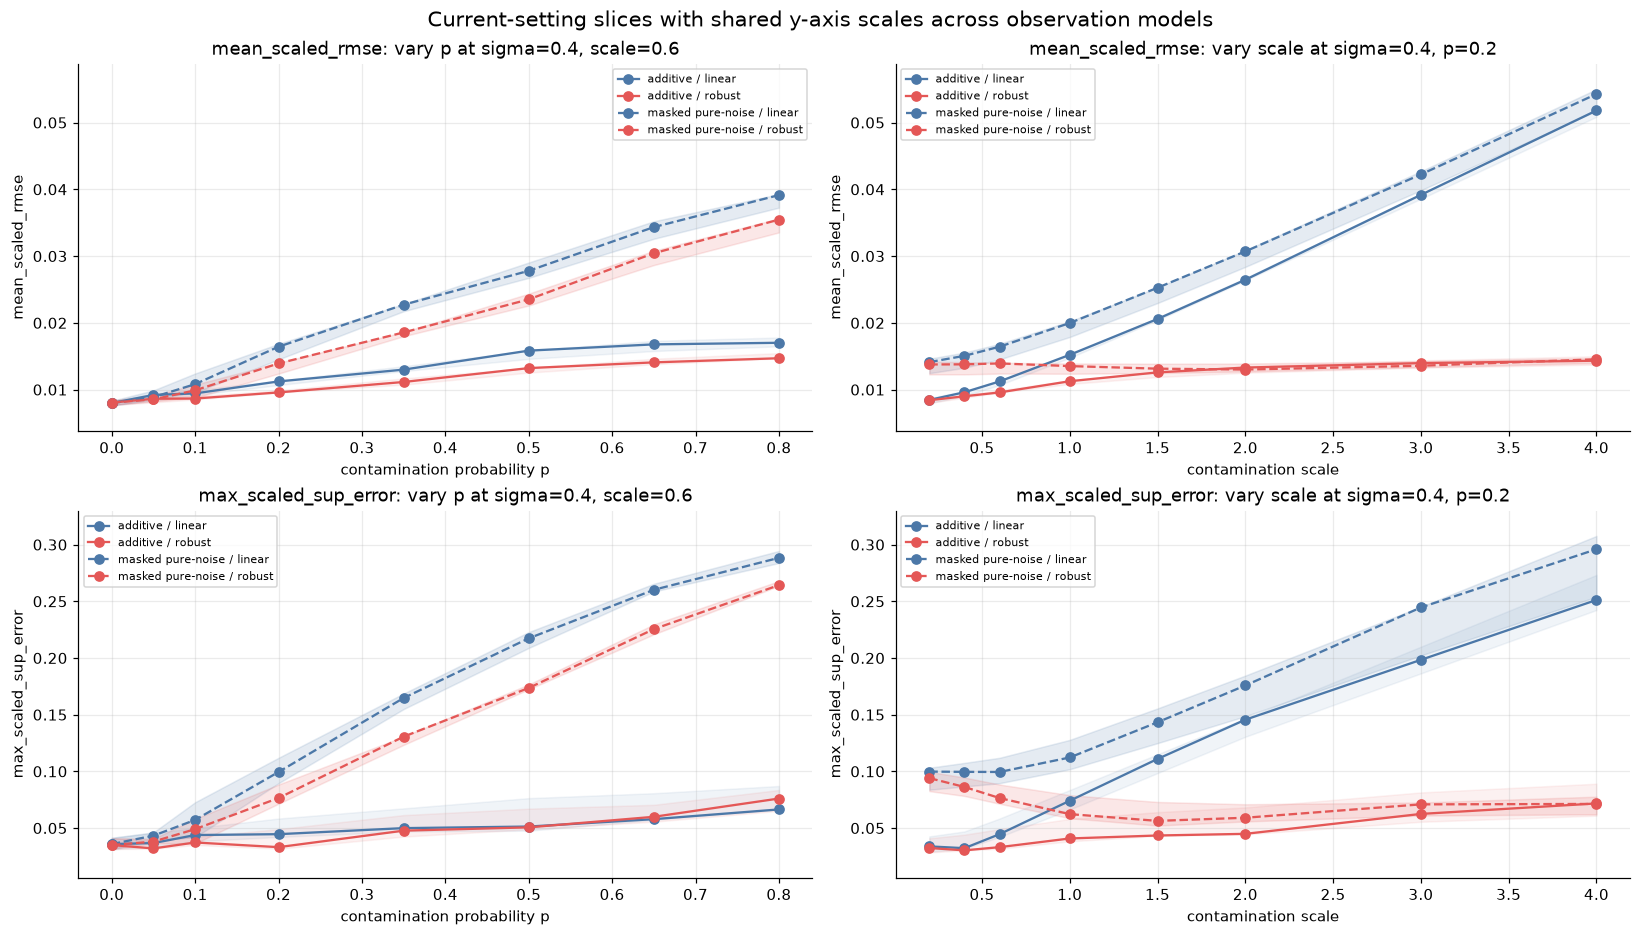

In [11]:
def summarize_slice(frame, varying_column, fixed_filters, metric):
    mask = np.ones(len(frame), dtype=bool)
    for column, value in fixed_filters.items():
        mask &= np.isclose(frame[column].to_numpy(dtype=float), float(value))
    filtered = frame.loc[mask].copy()
    rows = []
    for (method, value), group in filtered.groupby(["method", varying_column], sort=True):
        metric_values = group[metric].to_numpy(dtype=float)
        rows.append({
            "method": method,
            varying_column: float(value),
            "median": float(np.median(metric_values)),
            "q25": float(np.quantile(metric_values, 0.25)),
            "q75": float(np.quantile(metric_values, 0.75)),
        })
    return pd.DataFrame(rows)


def plot_current_setting_slices_shared(filename):
    metrics = ["mean_scaled_rmse", "max_scaled_sup_error"]
    fig, axes = plt.subplots(len(metrics), 2, figsize=(14.8, 8.4), constrained_layout=True)
    axes = np.atleast_2d(axes)
    current = limit_models["additive"]

    for row, metric in enumerate(metrics):
        all_y_values = []
        slice_cache = {}
        for model, ns in limit_models.items():
            aggregate = ns["aggregate_metrics"]
            p_slice = summarize_slice(
                aggregate,
                "contamination_probability",
                {"sigma": ns["CURRENT_SIGMA"], "contamination_scale": ns["CURRENT_CONTAMINATION_SCALE"]},
                metric,
            )
            scale_slice = summarize_slice(
                aggregate,
                "contamination_scale",
                {"sigma": ns["CURRENT_SIGMA"], "contamination_probability": ns["CURRENT_CONTAMINATION_PROB"]},
                metric,
            )
            slice_cache[(model, "p")] = p_slice
            slice_cache[(model, "scale")] = scale_slice
            all_y_values.extend([p_slice["median"], p_slice["q25"], p_slice["q75"], scale_slice["median"], scale_slice["q25"], scale_slice["q75"]])
        y_limits = min_max_limits(*all_y_values, pad_fraction=0.08)

        for model in ["additive", "masked"]:
            for method, group in slice_cache[(model, "p")].groupby("method"):
                group = group.sort_values("contamination_probability")
                axes[row, 0].plot(
                    group["contamination_probability"],
                    group["median"],
                    marker="o",
                    color=METHOD_COLORS[method],
                    linestyle=MODEL_LINESTYLES[model],
                    linewidth=1.5,
                    label=f"{MODEL_SHORT_LABELS[model]} / {method}",
                )
                axes[row, 0].fill_between(
                    group["contamination_probability"],
                    group["q25"],
                    group["q75"],
                    color=METHOD_COLORS[method],
                    alpha=0.08 if model == "additive" else 0.14,
                )
            for method, group in slice_cache[(model, "scale")].groupby("method"):
                group = group.sort_values("contamination_scale")
                axes[row, 1].plot(
                    group["contamination_scale"],
                    group["median"],
                    marker="o",
                    color=METHOD_COLORS[method],
                    linestyle=MODEL_LINESTYLES[model],
                    linewidth=1.5,
                    label=f"{MODEL_SHORT_LABELS[model]} / {method}",
                )
                axes[row, 1].fill_between(
                    group["contamination_scale"],
                    group["q25"],
                    group["q75"],
                    color=METHOD_COLORS[method],
                    alpha=0.08 if model == "additive" else 0.14,
                )
        for ax in axes[row, :]:
            ax.set_ylim(*y_limits)
            ax.legend(loc="best", fontsize=7)
        axes[row, 0].set_title(f"{metric}: vary p at sigma={current['CURRENT_SIGMA']:g}, scale={current['CURRENT_CONTAMINATION_SCALE']:g}")
        axes[row, 0].set_xlabel("contamination probability p")
        axes[row, 0].set_ylabel(metric)
        axes[row, 1].set_title(f"{metric}: vary scale at sigma={current['CURRENT_SIGMA']:g}, p={current['CURRENT_CONTAMINATION_PROB']:g}")
        axes[row, 1].set_xlabel("contamination scale")
        axes[row, 1].set_ylabel(metric)

    fig.suptitle("Current-setting slices with shared y-axis scales across observation models", fontsize=14)
    save_figure(fig, filename)
    return fig


fig = plot_current_setting_slices_shared("current_setting_slices_shared_scale.png")
plt.show()

## Export validation

This cell verifies that all planned TeX-ready figures were created and that they are non-empty.

In [12]:
EXPECTED_EXPORTS = [
    "observations_shared_scale.png",
    "robust_imf_grid_top_shared_scale.png",
    "robust_imf_grid_bottom_shared_scale.png",
    "robust_rmse_trends_shared_scale.png",
    "robust_sup_error_trends_shared_scale.png",
    "robust_error_boxplots_shared_scale.png",
    "error_surfaces_mean_scaled_rmse_shared_scale.png",
    "error_surfaces_max_scaled_sup_error_shared_scale.png",
    "baseline_degradation_mean_scaled_rmse_shared_scale.png",
    "baseline_degradation_max_scaled_sup_error_shared_scale.png",
    "current_setting_slices_shared_scale.png",
]

export_rows = []
for filename in EXPECTED_EXPORTS:
    path = FIGURE_DIR / filename
    export_rows.append({
        "filename": filename,
        "exists": path.exists(),
        "bytes": path.stat().st_size if path.exists() else 0,
    })
export_manifest = pd.DataFrame(export_rows)
assert export_manifest["exists"].all()
assert (export_manifest["bytes"] > 0).all()

export_manifest

,filename,exists,bytes
0,observations_shared_scale.png,True,458330
1,robust_imf_grid_top_shared_scale.png,True,609993
2,robust_imf_grid_bottom_shared_scale.png,True,1065324
3,robust_rmse_trends_shared_scale.png,True,245782
4,robust_sup_error_trends_shared_scale.png,True,262211
5,robust_error_boxplots_shared_scale.png,True,157233
6,error_surfaces_mean_scaled_rmse_shared_scale.png,True,198399
7,error_surfaces_max_scaled_sup_error_shared_sca...,True,184728
8,baseline_degradation_mean_scaled_rmse_shared_s...,True,399725
9,baseline_degradation_max_scaled_sup_error_shar...,True,418242
